In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("elahehgolrokh/data-science-job-postings-with-salaries-2025")

print("Path to dataset files:", path)

Path to dataset files: /Users/lavin/.cache/kagglehub/datasets/elahehgolrokh/data-science-job-postings-with-salaries-2025/versions/2


# Data Science Job Market Analysis (2025)

## Dataset Inspection

In this section, I load the dataset and perform an initial inspection to understand its structure.

The goals of this step are:

- Identify the available variables and features
- Determine the size of the dataset
- Examine the first few records
- Understand the information available for future analysis

This initial exploration provides the foundation for subsequent data cleaning, visualization, and job market analysis.

In [3]:
import os
import pandas as pd

print("=" * 50)
print("DATASET PATH:")
print(path)

print("\n" + "=" * 50)
print("FILES IN DATASET:")
print(os.listdir(path))

# Find CSV file automatically
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

print("\n" + "=" * 50)
print("CSV FILES FOUND:")
print(csv_files)

# Load first CSV
csv_path = os.path.join(path, csv_files[0])

print("\n" + "=" * 50)
print("LOADING:")
print(csv_path)

df = pd.read_csv(csv_path)

print("\n" + "=" * 50)
print("DATASET SHAPE:")
print(df.shape)

print("\n" + "=" * 50)
print("COLUMNS:")
print(df.columns.tolist())

print("\n" + "=" * 50)
print("FIRST 5 ROWS:")
display(df.head())

DATASET PATH:
/Users/lavin/.cache/kagglehub/datasets/elahehgolrokh/data-science-job-postings-with-salaries-2025/versions/2

FILES IN DATASET:
['feature_engineering.py', 'data_science_job_posts_2025.csv']

CSV FILES FOUND:
['data_science_job_posts_2025.csv']

LOADING:
/Users/lavin/.cache/kagglehub/datasets/elahehgolrokh/data-science-job-postings-with-salaries-2025/versions/2/data_science_job_posts_2025.csv

DATASET SHAPE:
(944, 13)

COLUMNS:
['job_title', 'seniority_level', 'status', 'company', 'location', 'post_date', 'headquarter', 'industry', 'ownership', 'company_size', 'revenue', 'salary', 'skills']

FIRST 5 ROWS:


,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]


## Initial Observations

After loading the dataset, I examined:

- The total number of observations (job postings)
- The available columns and features
- The format of salary and skills information
- The overall structure of the dataset

Understanding the dataset structure is an important first step before conducting any statistical analysis or visualization.

## Dataset Summary

The dataset contains **944 job postings** and **13 features** describing various aspects of data science positions.

### Available Features

The dataset includes information on:

- Job title
- Seniority level
- Work arrangement (remote, hybrid, on-site)
- Company identifier
- Job location
- Posting date
- Company headquarters
- Industry
- Ownership type
- Company size
- Revenue
- Salary
- Required skills

### Initial Observations

- The dataset appears to focus on data science-related positions.
- Salary information is available for most postings and is reported in euros.
- Skills are stored as lists of technologies and competencies required for each role.
- Work arrangements include remote, hybrid, and on-site opportunities.
- Company information includes industry, ownership, size, and revenue, which may be useful for salary and market analyses.

### Potential Questions for Analysis

This dataset may be used to investigate:

1. Which technical skills are most frequently requested?
2. Which skills are associated with higher salaries?
3. How do salaries differ by seniority level?
4. How do salaries differ between remote, hybrid, and on-site roles?
5. Which industries hire the most data scientists?
6. What characteristics are common among higher-paying positions?

In [4]:
display(df["skills"].head(10))

0    ['spark', 'r', 'python', 'scala', 'machine lea...
1    ['spark', 'r', 'python', 'sql', 'machine learn...
2    ['aws', 'git', 'python', 'docker', 'sql', 'mac...
3                               ['sql', 'r', 'python']
4                                                   []
5    ['scikit-learn', 'python', 'scala', 'sql', 'ma...
6                                                   []
7                                 ['machine learning']
8                                                   []
9                                                   []
Name: skills, dtype: str

## Skills Column Inspection

The skills column contains lists of technical skills associated with each job posting.

Examples include:

- Python
- SQL
- AWS
- Spark
- Docker
- R
- Machine Learning

During inspection, I observed that the skills data is currently stored as text strings (`dtype: str`) rather than native Python lists.

Before performing skill frequency analysis, the column will need to be converted into a structured format that allows individual skills to be extracted and counted.

Additionally, some job postings contain empty skill lists, indicating missing or unavailable skill information.

In [5]:
type(df["skills"][0])
df["skills"][0]

import ast
df["skills"] = df["skills"].apply(ast.literal_eval)

type(df["skills"][0])
df["skills"][0]

['spark', 'r', 'python', 'scala', 'machine learning', 'tensorflow']

In [6]:
from collections import Counter

all_skills = []

for skills in df["skills"]:
    all_skills.extend(skills)

skill_counts = Counter(all_skills)

skill_counts.most_common(20)

[('python', 640),
 ('machine learning', 580),
 ('sql', 442),
 ('r', 343),
 ('aws', 218),
 ('deep learning', 178),
 ('tensorflow', 165),
 ('spark', 161),
 ('azure', 155),
 ('pytorch', 148),
 ('tableau', 116),
 ('gcp', 106),
 ('scikit-learn', 91),
 ('scala', 85),
 ('database', 83),
 ('pandas', 76),
 ('java', 73),
 ('hadoop', 67),
 ('git', 65),
 ('numpy', 60)]

## Skill Frequency Analysis

To better understand the current data science job market, I analyzed the frequency of technical skills appearing in job postings.

The objective is to identify which tools, programming languages, and technologies are most commonly requested by employers.

These findings may help job seekers prioritize skills that are most relevant in today's market.

## Most Requested Skills

After aggregating skill requirements across all job postings, several clear patterns emerged.

### Top Technical Skills

| Skill | Frequency |
|---------|---------:|
| Python | 640 |
| Machine Learning | 580 |
| SQL | 442 |
| R | 343 |
| AWS | 218 |
| Deep Learning | 178 |
| TensorFlow | 165 |
| Spark | 161 |
| Azure | 155 |
| PyTorch | 148 |

### Key Observations

- Python is the most frequently requested technical skill, appearing in over two-thirds of job postings.
- SQL is the third most requested skill, demonstrating its importance for data science and analytics roles.
- Cloud technologies such as AWS, Azure, and GCP appear frequently.
- Machine learning and deep learning remain highly valued skills.
- PyTorch and TensorFlow are both common requirements for machine learning positions.

 gap in data engineering and analytics... SQL.

## Skill-Salary Analysis

Skill frequency alone does not indicate value.

To better understand which skills may be associated with higher compensation, I will compare salary distributions across different technical skills.

This analysis may reveal which technologies are most strongly associated with higher-paying data science roles.

In [7]:
df["salary"].head(20)

0     €100,472 - €200,938
1                €118,733
2      €94,987 - €159,559
3     €112,797 - €194,402
4     €114,172 - €228,337
5     €196,371 - €251,170
6       €51,330 - €70,144
7     €121,480 - €132,440
8                €207,331
9                €219,201
10                €96,815
11      €62,697 - €89,293
12     €99,464 - €165,954
13    €112,343 - €117,823
14    €127,867 - €150,700
15               €134,266
16                €52,746
17    €126,956 - €198,196
18    €185,412 - €228,338
19                €80,123
Name: salary, dtype: str

## Salary Column Inspection

The salary column is currently stored as text rather than a numeric data type.

Two primary formats are present:

1. A single salary value (e.g., €118,733)
2. A salary range (e.g., €100,472 - €200,938)

Because numerical analysis requires a single numeric value, the salary data must be transformed into a consistent format.

For this project, salary ranges will be converted to their midpoint values, providing a single representative salary estimate for each posting.

In [8]:
df["salary"].sample(10)

148               €137,002
808                €19,777
389    €189,520 - €205,503
630    €117,457 - €213,904
725                 €9,584
901    €118,677 - €220,789
353               €114,170
78     €153,442 - €210,981
146    €109,600 - €182,666
743    €115,179 - €208,201
Name: salary, dtype: str

In [9]:
def clean_salary(salary_str):

    salary_str = salary_str.replace("€", "")
    salary_str = salary_str.replace(",", "")

    if "-" in salary_str:

        low, high = salary_str.split(" - ")

        low = float(low)
        high = float(high)

        return (low + high) / 2

    else:

        return float(salary_str)
    
df["salary_clean"] = df["salary"].apply(clean_salary)
df[["salary", "salary_clean"]].head(10)

,salary,salary_clean
0,"€100,472 - €200,938",150705.0
1,"€118,733",118733.0
2,"€94,987 - €159,559",127273.0
3,"€112,797 - €194,402",153599.5
4,"€114,172 - €228,337",171254.5
5,"€196,371 - €251,170",223770.5
6,"€51,330 - €70,144",60737.0
7,"€121,480 - €132,440",126960.0
8,"€207,331",207331.0
9,"€219,201",219201.0


In [10]:
df["salary_clean"].describe()

count    9.440000e+02
mean     1.317795e+05
std      1.288144e+05
min      7.055000e+03
25%      7.637175e+04
50%      1.347240e+05
75%      1.697330e+05
max      2.739979e+06
Name: salary_clean, dtype: float64

## Salary Distribution Inspection

Summary statistics suggest the presence of extremely large salary values.

The maximum salary exceeds €2.7 million, which is substantially larger than the median salary of approximately €135k.

Before drawing conclusions from salary analyses, it is important to investigate potential outliers and determine whether these observations represent legitimate high-paying positions or data-quality issues.

In [11]:
df.sort_values(
    by="salary_clean",
    ascending=False
)[["job_title", "seniority_level", "salary", "salary_clean"]].head(20)

,job_title,seniority_level,salary,salary_clean
536,data scientist,senior,"€2,739,979",2739979.0
702,data scientist,senior,"€2,283,322",2283322.0
108,data scientist,senior,"€639,348",639348.0
546,data scientist,senior,"€306,626",306626.0
601,data scientist,senior,"€306,623",306623.0
68,data scientist,senior,"€306,623",306623.0
143,data scientist,lead,"€294,100",294100.0
885,data scientist,lead,"€264,761 - €302,202",283481.5
629,data scientist,lead,"€262,864 - €300,036",281450.0
602,data scientist,lead,"€262,862 - €300,034",281448.0


## Outlier Investigation

Inspection of the highest salaries revealed several unusually large values exceeding €2 million.

These observations are substantially larger than the majority of salaries in the dataset and may represent:

- Extreme outliers
- Synthetic or generated salary values
- Data collection artifacts

Additionally, several high-paying positions contain nearly identical salary ranges, suggesting that some salary values may have been programmatically generated rather than directly scraped.

Future analyses should consider the potential influence of these outliers on summary statistics.

In [12]:
df["seniority_level"].value_counts()

df["has_sql"] = df["skills"].apply(
    lambda skills: "sql" in skills
)

df.groupby("has_sql")["salary_clean"].mean()

has_sql
False    132221.061753
True     131277.998869
Name: salary_clean, dtype: float64

## SQL Salary Comparison

I compared average salaries between positions that explicitly mention SQL and those that do not.

### Findings

- Jobs mentioning SQL had an average salary of approximately €131,278.
- Jobs not mentioning SQL had an average salary of approximately €132,221.

### Interpretation

The difference is relatively small, suggesting that SQL alone may not be a strong predictor of salary within this dataset.

One possible explanation is that SQL is a common baseline skill across many data science positions and therefore does not strongly differentiate higher-paying roles.

Additional analyses may be required to evaluate the interaction between SQL, seniority level, job title, and other technical skills.

In [13]:
df.groupby("seniority_level")["salary_clean"].mean().sort_values()
df["seniority_level"].value_counts()

seniority_level
senior      630
lead        116
midlevel    113
junior       25
Name: count, dtype: int64

## Seniority Distribution

The dataset is heavily concentrated in senior-level positions.

### Distribution

- Senior: 630 postings
- Lead: 116 postings
- Midlevel: 113 postings
- Junior: 25 postings

### Implications

The dataset does not primarily represent entry-level hiring.

Instead, it is dominated by experienced data science roles.

As a result, salary analyses may be strongly influenced by seniority level and may not directly reflect the entry-level job market.

In [14]:
df.groupby("seniority_level")["salary_clean"].mean()

seniority_level
junior       87939.740000
lead        150339.099138
midlevel    100323.601770
senior      135549.150000
Name: salary_clean, dtype: float64

In [15]:
skill_salary = {}

for skill in all_skills:

    salaries = df[
        df["skills"].apply(lambda x: skill in x)
    ]["salary_clean"]

    if len(salaries) >= 20:
        skill_salary[skill] = salaries.mean()

sorted(
    skill_salary.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

[('scala', np.float64(157815.28235294117)),
 ('hadoop', np.float64(145732.31343283583)),
 ('spark', np.float64(145026.26708074534)),
 ('r', np.float64(142065.94314868803)),
 ('amazon', np.float64(140226.54901960783)),
 ('sql', np.float64(131277.9988687783)),
 ('azure', np.float64(128633.86774193548)),
 ('python', np.float64(128218.3015625)),
 ('tableau', np.float64(127467.45689655172)),
 ('gcp', np.float64(127326.45283018867)),
 ('database', np.float64(126868.53614457832)),
 ('aws', np.float64(125163.11697247706)),
 ('machine learning', np.float64(122509.55086206897)),
 ('tensorflow', np.float64(121355.86363636363)),
 ('linux', np.float64(118811.41304347826)),
 ('deep learning', np.float64(118126.86235955056)),
 ('java', np.float64(116129.25342465754)),
 ('pytorch', np.float64(113317.62162162163)),
 ('scikit-learn', np.float64(112981.46703296703)),
 ('airflow', np.float64(107009.84))]

# Results and Key Insights

This analysis explored 944 data science job postings from 2025 to identify relationships between skills, seniority, and salary.

## Dataset Characteristics

- Total postings analyzed: 944
- Features available: 13
- Primary variables included:
  - Job title
  - Seniority level
  - Work arrangement
  - Salary
  - Skills
  - Industry
  - Company information

## Most Frequently Requested Skills

The most common skills were:

| Skill | Frequency |
|---------|---------:|
| Python | 640 |
| Machine Learning | 580 |
| SQL | 442 |
| R | 343 |
| AWS | 218 |
| Deep Learning | 178 |
| TensorFlow | 165 |
| Spark | 161 |
| Azure | 155 |
| PyTorch | 148 |

### Interpretation

Python, machine learning, and SQL appear consistently throughout the data science job market, suggesting that these skills form the foundation of many data science roles.

---

## Salary Analysis

After cleaning salary values and converting ranges to midpoint estimates:

- Mean salary: €131,780
- Median salary: €134,724

Several extreme salary outliers exceeding €2 million were identified and should be interpreted cautiously.

---

## SQL vs Salary

Average salary by SQL requirement:

| SQL Mentioned | Average Salary (€) |
|---------------|------------------:|
| No | 132,221 |
| Yes | 131,278 |

### Interpretation

Contrary to expectations, SQL alone was not associated with significantly higher salaries.

This suggests SQL may function as a baseline skill expected across many roles rather than a differentiating factor.

---

## Salary by Seniority

| Seniority Level | Average Salary (€) |
|----------------|-------------------:|
| Junior | 87,940 |
| Midlevel | 100,324 |
| Senior | 135,549 |
| Lead | 150,339 |

### Interpretation

Seniority exhibited a much stronger relationship with salary than any individual skill.

The largest increase occurred between midlevel and senior positions.

---

## Highest-Paying Skills

Among skills appearing in at least 20 postings:

| Skill | Average Salary (€) |
|---------|------------------:|
| Scala | 157,815 |
| Hadoop | 145,732 |
| Spark | 145,026 |
| R | 142,066 |
| SQL | 131,278 |

### Interpretation

Skills associated with large-scale data processing and data engineering appear more frequently in higher-paying positions.

However, these relationships may be influenced by seniority and role specialization.

---

# Conclusion

The strongest predictor of salary in this dataset was seniority level rather than individual technical skills.

For aspiring data scientists, the results suggest focusing on foundational skills such as Python and SQL while developing experience that enables progression toward senior and lead-level roles.

Additionally, technologies associated with large-scale data systems (Spark, Hadoop, Scala) may represent valuable areas for future professional development.

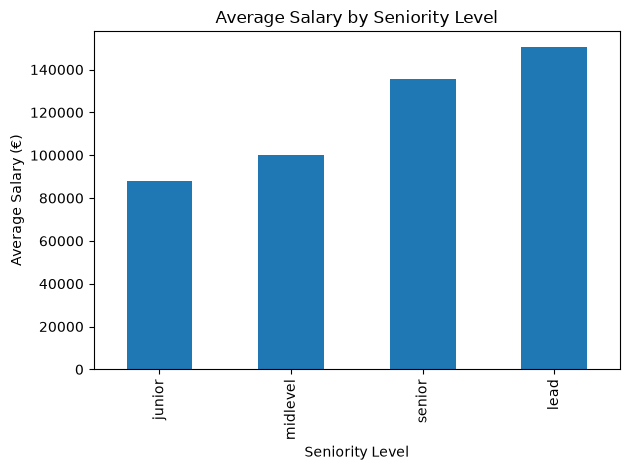

In [16]:
import matplotlib.pyplot as plt

salary_by_level = (
    df.groupby("seniority_level")["salary_clean"]
    .mean()
    .sort_values()
)

salary_by_level.plot(kind="bar")

plt.title("Average Salary by Seniority Level")
plt.ylabel("Average Salary (€)")
plt.xlabel("Seniority Level")

plt.tight_layout()
plt.savefig(

    "../images/ds_salary_by_seniority.png",

    dpi=300,

    bbox_inches="tight"

)
plt.show()